<a href="https://colab.research.google.com/github/minguzi-s/PyNps/blob/main/21_%EC%8B%A0%EA%B2%BD%EB%A7%9D_%EB%AA%A8%EB%8D%B8_%ED%9B%88%EB%A0%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 신경망 모델 훈련

In [ ]:
# 목표: 인공신경망 모델을 훈련하는 모범 사례와 필요한 도구들을 살펴보겠습니다.
#     이런 도구들을 다뤄 보면서 텐서플로와 keras API 에 더 익숙해 질겁니다.

# 핵심키워드 : 드롭아웃, 콜백, 조기종료
# 핵심 패키지와 함수 : Dropout,
#     save_weights(), load_weights(), save(), load_model()
#     ModelCheckpoint,  EarlyStopping
#     Numpy 의 argmax

# 데이터셋 : FashionMNIST

# GPU 사용시 학습 속도 향상

In [ ]:
# ● 사이킷런의 머신러닝 알고리즘 :
#   - 모델의 구조는 어느정도 '고정'
#   - 좋은 성능을 위해 '매개변수를 조정'하고 훈련하는 과정 반복
# ● 딥러닝 :
#   - 모델의 구조를 '직접' 만든다 (층을 추가, 뉴런의 개수, 활성화 함수 설정 등...)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow import keras

def set_seed(seed = 42):
  tf.keras.utils.set_random_seed(seed)
  # tf.config.experimental.enable_op_determinism()

# set_seed(42)

# 데이터 준비

In [ ]:
# 데이터 준비하기
from sklearn.model_selection import train_test_split

# 데이터 로딩
(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

# 전처리(정규화)
train_scaled = train_input / 255.0
test_scaled = test_input / 255.0   # ※ 이번단원에선 사용하지 않는다.

# train 데이터를 train:val = 8:2 로 분할
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

print(train_scaled.shape, train_target.shape)
print(val_scaled.shape, val_target.shape)
print(test_scaled.shape, test_target.shape)
# (48000, 28, 28) (48000,)
# (12000, 28, 28) (12000,)
# (10000, 28, 28) (10000,)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(48000, 28, 28) (48000,)
(12000, 28, 28) (12000,)
(10000, 28, 28) (10000,)


# History 객체

In [ ]:
# fit() 메소드의 리턴값 => History 객체
# History 객체에는 훈련과정에서 계산한 지표, 즉 loss 와 accuracy 값이 저장되어 있다.

In [ ]:
# '모델 만들기' 함수를 정의해보겠습니다.
# a_layer=  : 레이어를 받아서 hidden layer 추가
def model_fn(a_layer=None):
    set_seed(42)
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(28, 28)))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(100, activation='relu'))
    # 앞의 hidden layer(Dense) 뒤에 또 하나의 층을 추가하기
    if a_layer:
      model.add(a_layer)

    model.add(keras.layers.Dense(10, activation='softmax'))
    return model # 모델 객체 리턴


# 일단 a_layer= 매개변수를 지정하지 않고 호출해보기
model = model_fn()

model.summary()  # 이전에 만들었던 모델과 동일할 거다

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 이전과 동일하게 모델을 훈련하시만 fit() 메소드의 결과를 history 변수에 담아보겠습니다
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ↓ verbose= 는 훈련과정 출력을 조절
#   1 : (기본값) 이전에 보았던 것처럼 에포크마다 진행막대와 손실등의 지표를 출력
#   2 : 진행막대를 빼고 출력.
#   0 : 훈련과정을 나타내지 않기.
history = model.fit(train_scaled, train_target, epochs=5
                    , verbose=0 )

# history 객체에는 훈련 측정값이 담겨있는 history dict 가 들어있다.
print(type(history.history))  # dict

history.history

<class 'dict'>


{'accuracy': [0.8112499713897705,
  0.859291672706604,
  0.8733958601951599,
  0.8808333277702332,
  0.8868333101272583],
 'loss': [0.5311373472213745,
  0.39050817489624023,
  0.35173046588897705,
  0.3292568325996399,
  0.3137526512145996]}

In [ ]:
# ↓history 에는 'loss' 와 'accuracy' key 가 포함되어 있다.
history.history.keys()

# keras 는 epoch 마다 손실 계산한다.
# compile() 메소드에 metrics= 매개변수에 'accuracy' 를 추가했기 때문에
# history 속성에 포함되어 있는겁니다.

dict_keys(['accuracy', 'loss'])

In [ ]:
# 5번의 epoch 에 대한 loss 값 (list)
history.history['loss']

[0.5311373472213745,
 0.39050817489624023,
 0.35173046588897705,
 0.3292568325996399,
 0.3137526512145996]

In [ ]:
# 5번의 epoch 에 대한 accuracy 값 (list)
history.history['accuracy']

[0.8112499713897705,
 0.859291672706604,
 0.8733958601951599,
 0.8808333277702332,
 0.8868333101272583]

# 손실 곡선 loss curve

## Training Loss (훈련손실)

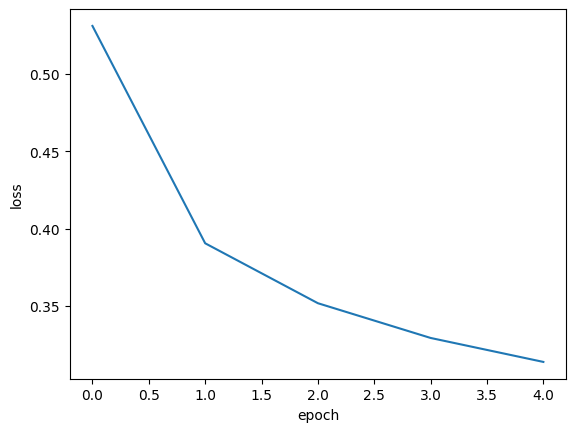

In [ ]:
# epoch 진행에 따른 loss 를 시각화 해보자
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

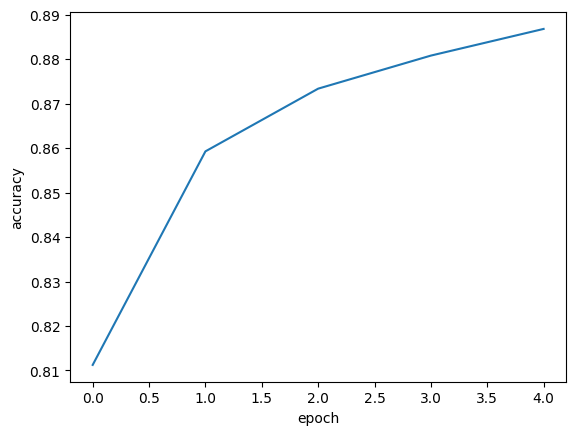

In [ ]:
# 정확도를 출력해보기
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [ ]:
# 에포크를 더 늘려보자! 더 좋아지지 않을까?

# ↓ 에포크 횟수를 20으로 늘려서 모델을 훈련하고 손실 그래프 출력해보자

In [ ]:
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=0)

history.history['loss']

[0.5311373472213745,
 0.39050817489624023,
 0.35173046588897705,
 0.3292568325996399,
 0.3137526512145996,
 0.2999352514743805,
 0.2894240915775299,
 0.28099459409713745,
 0.27200794219970703,
 0.26549163460731506,
 0.2580523192882538,
 0.2503543198108673,
 0.2475445568561554,
 0.2396693378686905,
 0.23506461083889008,
 0.23019538819789886,
 0.22596575319766998,
 0.22127117216587067,
 0.21800076961517334,
 0.21327564120292664]

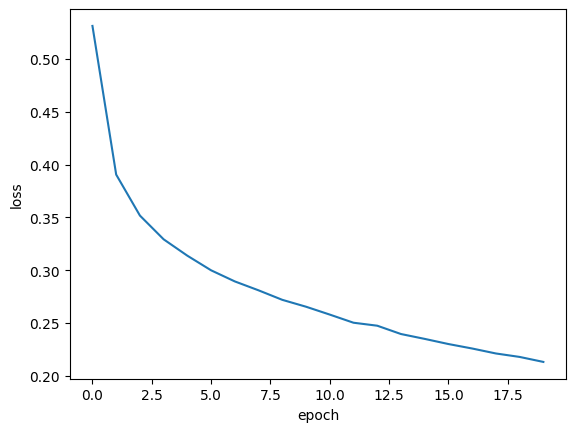

In [ ]:
# epoch 에 다른 loss 변화 시각화
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

## Validation Loss (검증손실)

In [ ]:
# 검증데이터에 대한 점수도 필요하다 -> 검증 손실!
#  왜?  overfit / underfit 여부 확인.


![](https://www.dropbox.com/scl/fi/bzohvd2ps1aurla95kpcg/validation-curve.jpg?rlkey=vce5j0jklntqjjuvxyua41svd&st=riftd2eb&dl=1)

In [ ]:
# 정확도 와 loss 값이 언제나 반비례는 아니다!

# 신경망모델에서 최적화 대상은 '정확도' 가 아니라 '손실함수' 다!

### validation_data= 매개변수 사용
fit() 의 매개변수

In [ ]:
# 에포크마다 '검증 손실'을 계산하기 위해 keras 모델의 fit() 메소드에 검증데이터를 전달할수 있다
#  validation_data= 매개변수에 검증에 사용할 입력과 타깃 값을 튜플로 만들어 전달한다.

model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target),
                    )

# ↓ history  에는 검증세트에 대한 손실은 val_loss 과 정확도 val_accuracy 에 들어있다
history.history.keys()


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8112 - loss: 0.5311 - val_accuracy: 0.8457 - val_loss: 0.4327
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8593 - loss: 0.3905 - val_accuracy: 0.8627 - val_loss: 0.3827
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8734 - loss: 0.3517 - val_accuracy: 0.8673 - val_loss: 0.3728
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8808 - loss: 0.3293 - val_accuracy: 0.8641 - val_loss: 0.3867
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8868 - loss: 0.3138 - val_accuracy: 0.8688 - val_loss: 0.3853
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8934 - loss: 0.2999 - val_accuracy: 0.8733 - val_loss: 0.3873
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8980 - loss: 0.2894 - val_accuracy: 0.8662 - val_loss: 0.4065
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9017 - loss: 0.2810 

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

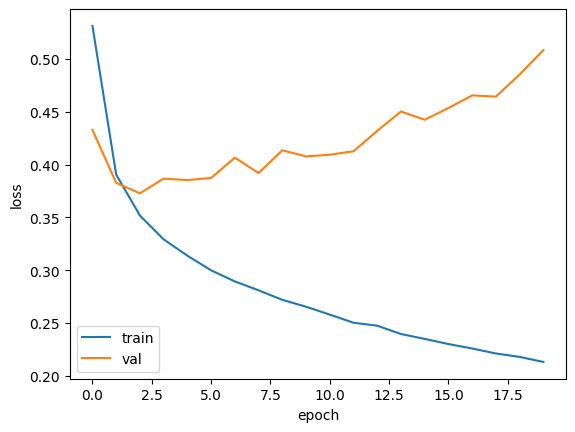

In [ ]:
# 과대, 과소 적합에 대한 문제를 조사하기 위한 그래프를 그려서 비교

plt.plot(history.history['loss'])  #  training loss
plt.plot(history.history['val_loss']) # validataion loss
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [ ]:
# overfit 을 막기 위한 '규제(regularization)'

# 일단은 'optimizer 의 파라미터'를 조정해서 overfit 막을수 있나 보자.

# RMSprop 대신 다른 옵티마이저 선택한다면 Adam 을 써보자.
#   Adam 은 'adaptive learning rate' 사용

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8159 - loss: 0.5220 - val_accuracy: 0.8465 - val_loss: 0.4286
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8597 - loss: 0.3905 - val_accuracy: 0.8575 - val_loss: 0.3881
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8730 - loss: 0.3490 - val_accuracy: 0.8635 - val_loss: 0.3689
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8834 - loss: 0.3215 - val_accuracy: 0.8732 - val_loss: 0.3513
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8896 - loss: 0.3026 - val_accuracy: 0.8734 - val_loss: 0.3487
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8952 - loss: 0.2858 - val_accuracy: 0.8773 - val_loss: 0.3404
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8989 - loss: 0.2724 - val_accuracy: 0.8798 - val_loss: 0.3375
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9044 - loss: 0.2597 - 

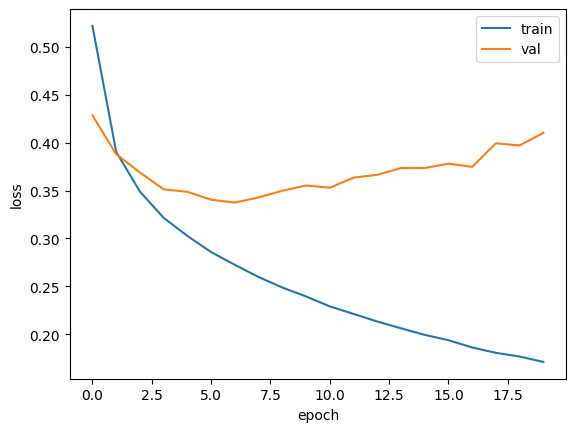

In [ ]:
# Adam 옵티마이저 사용하여 훈련손실과 검증 손실 측정하기
model = model_fn()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20,
                    # verbose=0, # 학습중 출력내용 없애기
                    validation_data=(val_scaled, val_target))

# loss curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [ ]:
# ↑ validation loss 를 보면 과대적합이 성향이 많이 억제된게 보인다.
# 여전히 요동치고는 있지만, 열번째 에포크 까지는 전반적인 감소 추세가 이어지고 있다.
# 이는 Adam 옵티마이저가 이 데이터셋에 잘 맞는다는 것을 보여준다.

# 더 나은 손실 곡선을 얻으려면 '학습률'을 조정해서 다시 시도해 볼수도 있다.
# (이는 나중에 각자 도전해보자)

# ↓ 이제 신경망에서 사용하는 대표적인 규제(regularization) 방법을 알아보자


# Dropout 드롭아웃

- 신경망에서 사용되는 대표적인 규제 (regularization)
- 제프리 힌터 (Geoffrey Hinton) 이 소개
- '훈련과정' 에서 층에 있는 일부 뉴런을 랜덤하게 꺼서 (즉 뉴런의 출력을 0으로 만들어)
과대 적합을 억제

![](https://www.dropbox.com/scl/fi/5r3skf02xk8gn44eg2v6w/dropout01.png?rlkey=nixyklwzqituqhh38vmqb7emd&st=h037wocc&dl=1)

In [ ]:
#  '훈련과정' 에서 층에 있는 일부 뉴런을 랜덤하게 꺼서 (즉 뉴런의 출력을 0으로 만들어)
# 과대 적합을 억제


In [ ]:
#  '훈련과정' 에서 층에 있는 일부 뉴런을 랜덤하게 꺼서 (즉 뉴런의 출력을 0으로 만들어)
# 과대 적합을 억제

# 왜 과대적합을 막을까?
#  - 특정 뉴런에 과대하게 의존하는 것을 줄여, 신경망이 더 안정적인 예측을 만들수 있다.
#  - 마치 여러개의 신경망을 '앙상블' 하는 것처럼 동작한다.  이또한 과대적합을 막아주는 좋은 기법.


# keras 의 드롭아웃은 keras.layers.Dropout 클래스로 제공
# 어떤 층의 뒤에 Dropout 을 두어 이 층의 출력을 랜덤하게 0 으로 만들어 준다.
# Dropout 은 '층' 처럼 사용되지만 훈련되는 모델 파라미터는 없습니다.


**tf.keras.layers.Dropout**

https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout

```python
tf.keras.layers.Dropout(
    rate,  # 0.0 ~ 1.0
    noise_shape=None,
    seed=None,
    **kwargs
)
```

In [ ]:
# 앞서 정의한 model_fn() 함수에 드롭아웃 객체를 전달하여 층을 추가해보자
model.summary()  # 직전 모델 확인

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,532 (931.77 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 159,022 (621.18 KB)

In [ ]:
model = model_fn(keras.layers.Dropout(rate=0.3))   # 30% 정도 드롭아웃 하기 (이것은 하이퍼 파라미터다)
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Dropout
#   - 모델 파라미터 없다!
#   - 입력과 출력의 크기 같다.
#     - 출력을 0으로 만들뿐 출력배열의 크기는 동일.
#   - '훈련' 할때만 동작.
#   - '평가' , '예측' 할때는 동작하지 않는다.


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7939 - loss: 0.5893 - val_accuracy: 0.8472 - val_loss: 0.4312
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8424 - loss: 0.4405 - val_accuracy: 0.8620 - val_loss: 0.3793
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8541 - loss: 0.4056 - val_accuracy: 0.8674 - val_loss: 0.3645
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8595 - loss: 0.3836 - val_accuracy: 0.8698 - val_loss: 0.3529
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8663 - loss: 0.3689 - val_accuracy: 0.8758 - val_loss: 0.3414
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8711 - loss: 0.3524 - val_accuracy: 0.8748 - val_loss: 0.3446
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8742 - loss: 0.3449 - val_accuracy: 0.8776 - val_loss: 0.3385
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8758 - loss: 0.3363 - 

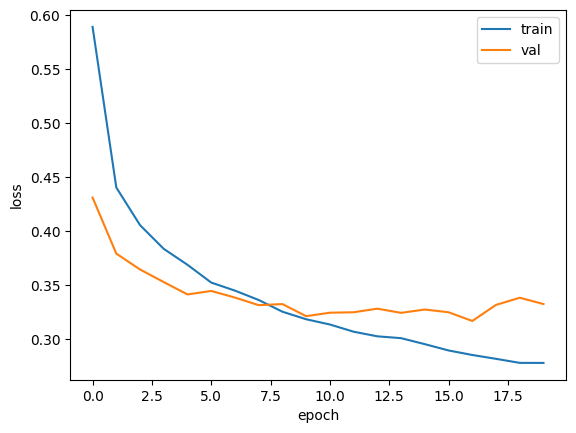

In [ ]:
# 이전과 마찬가지로 훈련 손실과 검증 손실의 그래프를 그려 비교해 보겠습니다.
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20,
                    verbose=1,
                    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# Keras 모델 저장과 복원
- Keras 모델의 구성요소
  - 모델의 구조 (레이어, 연결방법등..)
  - weight 값 (모델의 상태)
  - 옵티마이저 (모델을 compile 하여 정의됨)
- Keras 는 이 요소들을 한번에 모두 저장하거나, 혹은 일부만 저장할수 있다


- 참조: https://www.tensorflow.org/guide/keras/save_and_serialize?hl=ko

In [ ]:
# epoch 횟수를 10으로 다시 지정하고 모델 훈련,  그리고 이 훈련된 모델을 저장해보겠습니다

# model = model_fn(keras.layers.Dropout(0.3))
# model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])

# history = model.fit(train_scaled, train_target, 🔹TODO,
#                     validation_data=(val_scaled, val_target))

In [ ]:
# 모델 '저장'과 '복원'.  두가지 방식으로 해볼거다
# 1. 훈련을 하지 않은 새로운 모델을 만들고 model.weights.h5 파일에서 훈련된 모델 파라미터를 읽어서 사용해보기
# 2. 아예 model-whole.keras 파일에서 새로운 모델을 만들어 사용해보기

## save_weights(), load_weights()
- save_weights()
  - 훈련된 모델의 weight 들을 저장
  - 저장포맷 2가지
    1. Tensorflow 체크포인트 포맷 (디폴트)
    1. HDF5 포맷
      - save_format='h5'
      - 혹은 *.h5 또는 *.hdf5 로 끝나는 파일로 저장
- load_weight()


In [ ]:
model.save_weights('model.weights.h5')  # 파일명은 *.weights.h5 로 끝나야 한다

In [ ]:
#  load_weights() 를 사용하여 복원하려면
#  save_weights() 로 저장했던 모델과 정확히 같은 구조를 가져야 한다
#  그렇지 않으면 에러!

In [ ]:
new_model = model_fn(keras.layers.Dropout(0.3))  # 새로운 모델 생성!
new_model.load_weights('model.weights.h5') # 모델 파라미터 읽어오기

In [ ]:
# .evaluate() 해보면?
# new_model.evaluate(val_scaled, val_target)

ValueError: You must call `compile()` before using the model.

- predict()

In [ ]:
# 이 모델의 검증 정확도를 확인해볼겁니다.

# keras 의 predict() 는 사이킷럿과 달리 샘플마다 10개의 클래스에 대한 확률을 리턴한다
#  ↑ FashionMNIST 는 다중 분류 문제이기 때문이다.
#   (이진 분류 문제라면 양성 클래스에 대한 확률 하나만 반환한다.)

# keras 에도 '확률' 대신 '클래스' 로 예측해주는 메소드가 있긴 하다 -> predict_classes()
#  그러나 predict_classes() 는 deprecated 되었고,
#  keras 공식에도 predict() 를 권장하고 있다.

# FasionMNIST 덜어낸 검증 세트의 샘플 개수는 12,000개이기 때문에
#  predict() 는 (12000, 10) 크기의 배열을 리턴할거다 (아래그림)

# 따라서 조금 번거롭지만 10개 활률중에 가장 큰 값의 인덱스를 골라
# 타겟 레이블과 비교하여 정확도를 계산해봅니다.

![](https://www.dropbox.com/scl/fi/wiptm6pk5i7s2tfqosskn/model_output01.jpg?rlkey=nyn36jofy7kvty3xqayfx3c2m&st=pxb0egs7&dl=1)

In [ ]:
# 잠깐!]  왜 evaluate() 를 사용하지 않나요?
#  모델 파라미터를 읽은 후 evaluate() 메소드를 사용하여 정확도를 출력할 수도 있습니다.
#  하지만! evaluate() 메소드는 손실을 계산하기 위해 반드시 먼저 compile() 메소드를 실행해야 합니다.
#  여기에서는 새로운 데이터에 대한 정확도만 계산하면 되는 상황이라 가정합니다.

In [ ]:
# ↓ predict() 결과에서 '가장 큰 값' 을 고르기 위헤 np.argmax() 사용. <- 배열에서 가장 큰 값의 '인텍스' 를 리턴
# (다행히 FasionMNIST 의 타겟값도 0부터 시작하기에, 위 결과 index 와 비교하기 좋다.  그러하 헷갈리진 말자)

# axis=-1  : 배열의 마지막 차원을 따라 최댓값을 고릅니다.
#  검증세트는 2차원 배열이기 때문에 마지막 차원은 1이 된다.
#  axis=1 이면 열을 따라 각 행의 최댓값의 인덱스를 선택하고,
#  axis=0 이면 행을 따라 각 열의 최댓값의 인덱스를 선택한다. (아래 그림)
val_labels = np.argmax(new_model.predict(val_scaled), axis=-1)

print(val_labels.shape)  # (12000, )
val_labels # array([8, 8, 7, ..., 8, 8, 9])

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
(12000,)


array([8, 8, 7, ..., 8, 8, 0])

![](https://www.dropbox.com/scl/fi/ejh4lld670aq5d5b0s178/model_output02.jpg?rlkey=fh0bi7e1apjf8qtnmg4hz7uns&st=h6nayabc&dl=1)

In [ ]:
# ↓ argmax() 로 고른 인덱스(val_labels) 와 타깃(val_target) 을 비교합니다.
#  두 배열에서 각 위치의 값이 같으면 1이 되고 다르면 0이 됩니다.
#  이를 평균하면 '정확도' 가 되겠죠!
print(np.mean(val_labels == val_target))


0.8825833333333334


## save(), load_model()
- **model.save()**
  - https://www.tensorflow.org/api_docs/python/tf/keras/Model#save
  - 저장하는 것들
    - 모델구조
    - 훈련된 모델파라미터 (weights)
    - 모델의 컴파일 정보
      - 옵티마이저와 그 상태
  - 저장 형식 두가지
    1. TensorFlow SavedModel 포맷 (기본값)
    1. Keras H5 포맷
      - save_format= 파라미터는 Keras3 에서 deprecated 됨
      - 과거에는 .h5 확장자를 사용했으나 지금은 .keras 확장자만 사용하도록 강력권장됨
  - 내부적으로 keras.saving.save_model() 호출

- **keras.models.load_model.load_model()**
  - https://www.tensorflow.org/api_docs/python/tf/keras/models/load_model



In [ ]:
# save()
model.save('model-whole.keras')


In [ ]:
# load_model()
new_model = keras.models.load_model('model-whole.keras')
new_model.evaluate(val_scaled, val_target)  # 여기서는 왜 evaluate 사용? <- optimizer 정보도 갖고 있으니까!

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8826 - loss: 0.3325


[0.33251404762268066, 0.8825833201408386]

In [ ]:
# predict(데이터) => 예측값
# evaluate(데이터, 타켓) => 점수

# evaluate() 는 손실을 계산하기 위해 반드시 compile() 메소드를 실행해야 한다.
# save_model() 이 저장하는 모델은 모델구조와 옵티마이저 상태까지 저장
# load_model() 은 모델 + 파라미터 가져온다.  이때 모델구조와 옵티마이저 상태까지 모두 복원.


In [ ]:
# 그런데... 생각해보자.

# 20번의 에포크 동안 학습한뒤
# 검증손실이 상승하는 지점 파악후 다시 훈련?
# => 모델을 두번씩이나 학습한다??


# Callback 콜백
keras.callbacks

In [ ]:
# 콜백(callback) 은 '훈련 과정 중간' 에 어떤 작업을 수행할 수 있게 하는 객체
# fit() 의 callbacks= 매개변수로 전달하여 사용 (list)

## ModelCheckpoint 콜백

**tf.keras.callbacks.ModelCheckpoint**

https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint

```python
tf.keras.callbacks.ModelCheckpoint(
    filepath,  # 모델 저장 경로
    monitor='val_loss',
    verbose=0,
    save_best_only=False,  # True 이면 가장 낮은 검증 점수를 만드는 모델을 저장
    save_weights_only=False,
    mode='auto',
    save_freq='epoch',
    initial_value_threshold=None
)
```

In [ ]:
# ModelCheckPoint 콜백은 기본적으로 에포크마다 모델을 저장한다
#  save_best_only = True  지정하면 가장 낮은 검증 점수를 만드는 모델만 저장할 수 있다.

model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True)

model.fit(train_scaled, train_target, epochs=20, # 20번의 에포크!
          verbose=1,
          validation_data=(val_scaled, val_target),
          callbacks=[checkpoint_cb])   # callbacks=[...] 에 콜백 객체 전달

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7926 - loss: 0.5876 - val_accuracy: 0.8457 - val_loss: 0.4244
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8437 - loss: 0.4363 - val_accuracy: 0.8590 - val_loss: 0.3870
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8550 - loss: 0.4048 - val_accuracy: 0.8659 - val_loss: 0.3668
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8631 - loss: 0.3813 - val_accuracy: 0.8708 - val_loss: 0.3490
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8668 - loss: 0.3670 - val_accuracy: 0.8748 - val_loss: 0.3396
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8709 - loss: 0.3516 - val_accuracy: 0.8733 - val_loss: 0.3405
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8746 - loss: 0.3433 - val_accuracy: 0.8727 - val_loss: 0.3431
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8783 - loss: 0.3307 

In [ ]:
# 위 저장된 모델을 load_model() 함수로 읽어서 예측을 수행해보자

model = keras.models.load_model('best-model.keras')

model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8890 - loss: 0.3130


[0.3130427300930023, 0.8889999985694885]

## Early stopping(조기종료)

**tf.keras.callbacks.EarlyStopping**

https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping

```python
tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=0,
    verbose=0,
    mode='auto',
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0
)
```

In [ ]:
# ↑ModelCheckpoint 콜백을 통해 가장 낮은 검증점수의 모델을 자동 저장하긴 했으나!
# 여전히 20번의 에포크는 수행했다.

# 검증점수가 상승하기 시작하면 overfit 이 커지기 때문에
# 훈련을 계속할 필요가 없으므로!  훈련을 중지하여 컴퓨터의 시간과 자원 절약 가능.

# overfit 발생되기 전에 조기종료(early stopping)
# 조기종료 또한 규제(refularization) 의 한가지 방법.


- patience=
- restore_best_weights=

In [ ]:
# patience=
#    검증점수가 향상되지 않더라도 좀더 참고 수행할 에포크 횟수 지정.

# restore_best_weights=
#     True 로 지정하면 가장 낮은 검증 손실을 낸 파라미터로 되돌린다.

# ↓ 이 두 콜백을 함께 사용해 보겠습니다

In [ ]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

history = model.fit(train_scaled, train_target, epochs=20,
                    verbose=1,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])  # 두개의 콜백 지정

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7926 - loss: 0.5876 - val_accuracy: 0.8457 - val_loss: 0.4244
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8437 - loss: 0.4363 - val_accuracy: 0.8590 - val_loss: 0.3870
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8550 - loss: 0.4048 - val_accuracy: 0.8659 - val_loss: 0.3668
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8631 - loss: 0.3813 - val_accuracy: 0.8708 - val_loss: 0.3490
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8668 - loss: 0.3670 - val_accuracy: 0.8748 - val_loss: 0.3396
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8709 - loss: 0.3516 - val_accuracy: 0.8733 - val_loss: 0.3405
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8746 - loss: 0.3433 - val_accuracy: 0.8727 - val_loss: 0.3431


In [ ]:
# ↑ 훈련을 마치고 나면 몇번째 에포크에서 훈련이 중지 되었는지
# EarlyStopping 객체의 stopped_epoch 속성에서 확인 가능하다

early_stopping_cb.stopped_epoch   # 0-base

6

In [ ]:
# 위 에포크 값은 0-base 다
#  10 <- 11번째 epoch 에서 종료되었다.

# 따라서 최상의 모델은 9번째 epoch 에서 학습한 weight 값. (patience=2 였기 때문)


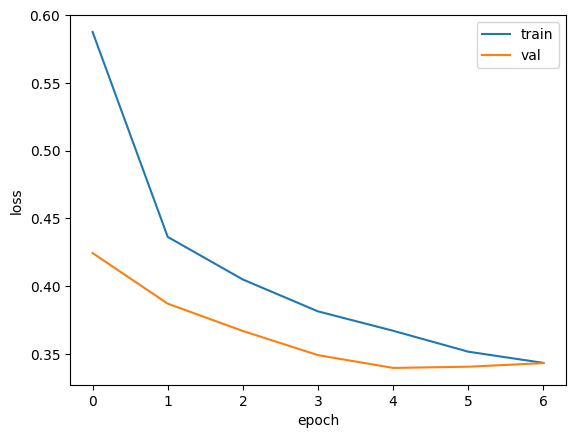

In [ ]:
# loss curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [ ]:
"""
↑ 네 맞습니다.  9번째 에포크에서 가장 낮은 손실을 기록했고, 11번째 에포크에서 훈련이 중지 되었습니다.
이렇게 조기종료 기법을 사용하면 안심하고 에포크 횟수를 크게 지정해도 괜찮습니다.

컴퓨터 자원과 시간을 아낄수 있고 ModelCheckPoint 콜백과 함께 사용하면 최상의 모델을 자동으로 저장해 주므로 편리합니다
"""
None

In [ ]:
# 마지막으로 조기종료로 얻은 모델을 사용해 검증 세트에 대한 성능을 확인해보겠습니다.
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8748 - loss: 0.3396


[0.33958983421325684, 0.874833345413208]

# 최상의 신경망 모델 얻기 (문제해결과정)
인공신경망 모델을 훈련하기 위한 다양한 도구를 학습했다

1. fit() 의 리턴값 을 사용해 훈련세트와 검증세트에 대한 손실을 그래프로 그릴 수 있습니다.  이를 위해 fit() 메소드는 훈련세트 뿐만 아니라 검증세트를 전달할수 있는 매개변수를 제공합니다.

1. DropOut : 과대적합을 막기 위한 인공신경망의 규제방법
  - 학습시 일부 뉴런의 출력을 랜덤하게 끔
  - 일부 뉴런에 과하게 의존하는 것을 막고
  - 마치 많은 신경망이 앙상블 하는 듯한 효과
1. 모델, 혹은 모델 파라미터 저장하고 복원하기
1. 콜백을 사용하면 과대 적합 되기전에 에포크를 종료. 최상의 모델 유지할수 있다
